<div class='alert alert-block alert-info"'>
<h1> Simulation study :</h1>

<h4> Variable selection and estimation in a joint model of logitic longitudinal data and survival data </h4>
</div>

In [1]:
import jax.numpy as jnp

from sdg4varselect.models.wcox_mem_joint_model import (
    get_params_star,
    create_logistic_weibull_jm,
)

from sdg4varselect.outputs_new import TestResults

import sdg4varselect.plot as sdgplt

sdgplt.FIGSIZE = 15


def read(n, p, c, s=2):
    """read files results for n and p as parameter"""
    model = create_logistic_weibull_jm(N=n, J=5, P=p)
    config = {"N": n, "J": 5, "P": p, "C": c}
    return TestResults.load(model, "files", f"C{c}_S{s}"), config


def read_multi_files(N, P, C, S=0):
    if len(N) == 1 and len(P) == 1 and len(C) == 1:
        out = [read(N[0], P[0], C[0], s=S)]
    elif len(N) == 1:
        out = [read(N[0], p, C[0], s=S) for p in P]
    elif len(P) == 1:
        out = [read(n, P[0], C[0], s=S) for n in N]
    else:
        out = [read(N[0], P[0], c, s=S) for c in C]

    return TestResults([o[0] for o in out], [o[1] for o in out])

In this section, we propose to study the performance of the procedure we have just presented. First of all, we want to show numerically the consistency of the estimator (ref{eq:penalized_estimator}) by studying 4 scenarios, varying the number of individuals observed. Then we'll demonstrate the method's ability to select variables by varying the number of covariates in the initial model. And finally with 3 relevant scenarios we will study the effect of censorship on the estimation procedure. This simulation study is conducted in the case of joint modeling for longitudinal logistic data, and a result for the pharmakokinetik model will also be presented in the end. In each scenario we generate independent data set and each time we fit the ref{eq:joint} model using the ref{algo:SPG-fim} routine described above (ref{algo:metho}).

Before anything else, to compare the next results of different scenarios, we look at the estimation error. We consider separately the relative root mean square errors $rrmse$ of the high dimensional parameters $\beta \in \mathbb R^p$ and of the low dimensional parameters, denotes by $\nu \in \mathbb R^d$ :
        
$$rrmse (\beta)  = \sqrt{\frac {||\beta -\hat\beta||^2}{p ||\beta||^2} } ~;~ rrmse (\nu)  = \sqrt{\frac 1d \sum_{i=1}^d  \frac {(\nu_i -\hat\nu_i)^2}{\nu_i^2 } }$$

# Logistic Joint-Model Specification

We first consider the joint model defined \ref{eq:joint} with the classical logistic function for the non-linear mixed effects model, defined by :

$$
    m: t \mapsto \dfrac{Z_1}{1 + \exp\left(\dfrac{Z_2-t}{Z_3}\right)},
$$

Where $Z_1$ represents the asymptotical maximum value of the curve, $Z_2$ represents the value of the sigmoid's midpoint, and $Z_3$ represents the logistic growth rate. 
We model for each individual $i$ the corresponding individual parameter $Z_i\in \mathbb R^3$ through a Gaussian random variable with expectation $\mu  \in \mathbb R^3$ and a diagonal variance $\Gamma=diag(\gamma_1^2,\gamma_2^2,0)$ meaning that the third parameter $\mu_3$ is modeled as a fixed effect. 

We consider a fixed Weibull baseline defined as $h_{a,b}(t)= b a^{-b} t^{b-1}$, where $a=80$ and $b=35$ are fixed (i.e. not estimated) in the simulation study. We focus in this simulation study on the selection of variables and on the inference  of the parameters of the mixed-effect model as well as  $\alpha$ the multiplicative parameter of the Cox model.

## Simulation setup

We generated 20 data set according to the joint model presented previously in Equation ref{eq:joint}. For each different value of $p$, we  choose the vector $\beta$ such that the first four components are equal to $(-2,-1,1,2)$ and the rest are equal to zero. Additionally, we generate the matrix of covariates $U$ with $N$ rows and $p$ columns, following a uniform distribution $U_{i,l} \sim \mathcal U([-1,1]) ; ~\forall i \in { 1, ..., N}, l\in{1,..., p}$. Afterwards, we renormalize all the matrix columns to obtain centered data. All the parameter values are detailed in the table ref{tab:truevalues} below.

In [2]:
params_star = get_params_star(create_logistic_weibull_jm(50, 5, 6))
print(str(params_star).replace(", dtype=float64),", "),\n\t  "))
params_star = jnp.hstack(get_params_star(create_logistic_weibull_jm(50, 5, 600)))

No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


Parameters(mu1=Array(0.3),
	   mu2=Array(90.),
	   mu3=Array(7.5),
	   gamma2_1=Array(0.0025),
	   gamma2_2=Array(20.),
	   sigma2=Array(0.001),
	   alpha=Array(110.11),
	   beta=Array([-2., -3.,  3.,  2.,  0.,  0.], dtype=float64))


## Consistancy of $\hat\theta_{MLE}$

In this part, we aim to show the numerical consistance of the proposed estimator ref{eq:penalized_estimator}, thus we focus on four scenarios where the number of individuals observed is increasing : $N\in\{50,100,200,300\}$ when the number of covariates $p = 200$ and the number of longitudinal observations $J = 5$ are fixed. 

In [3]:
results = read_multi_files(N=(100, 100), P=(100,), C=(0,), S=2)

model = create_logistic_weibull_jm(N=100, J=5, P=100)

params_star = jnp.hstack(get_params_star(model))
params_names = model.params_names

theta = jnp.array(results.last_theta)
print(theta.shape)

files/WCoxMemJM_N100_J5_P100_C0_S2 LOADED !
files/WCoxMemJM_N100_J5_P100_C0_S2 LOADED !
(2, 14, 3, 107)


In [39]:
chrono = jnp.array([[res.chrono.total_seconds() for res in reg] for reg in results[0]])
chrono[3:].mean(axis=0)

for reg in results[0]:
    print(reg.chrono)

3:07:12.217933
2:10:21.751333
0:13:25.047316
0:14:37.560870
0:15:28.695911
0:13:05.492670
0:13:57.854946
0:14:39.138821
0:14:03.553267
0:14:34.826873
0:13:42.172436
0:14:22.487829
0:14:34.963833
0:14:37.041687


The following graphe show the estimations for each parameter for the four scenarios

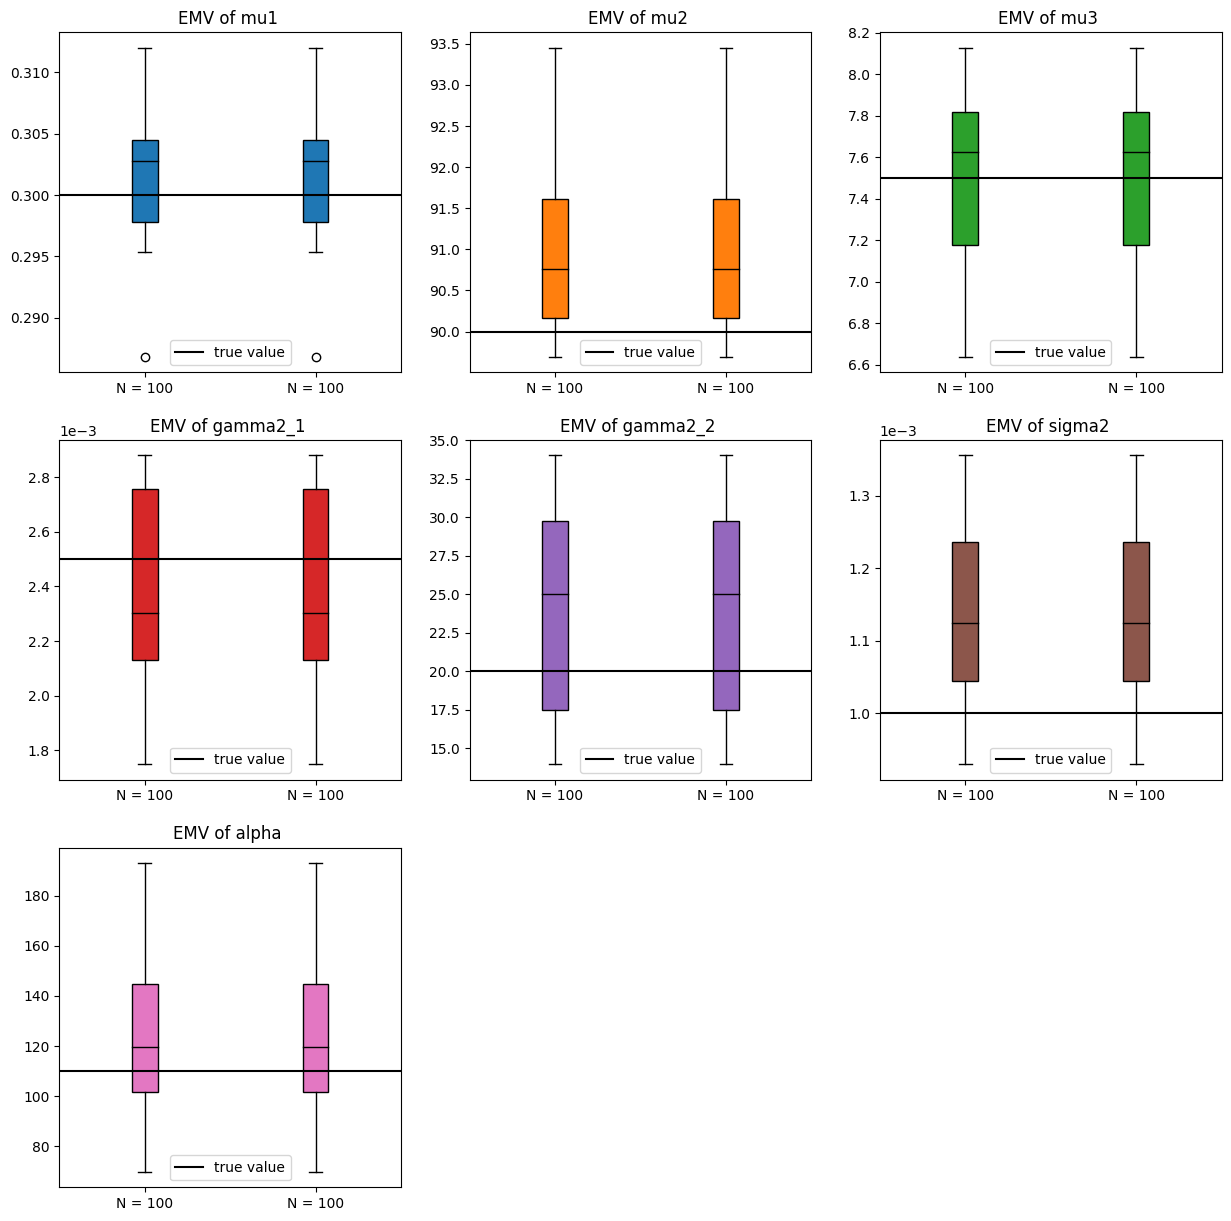

In [19]:
theta = jnp.array(results.last_theta)
scenarios_labels = results.get_scenarios_labels("N")

fig = sdgplt.figure()
for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(theta[:, :, -1, i], patch_artist=True, labels=scenarios_labels)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=params_star[i], color="k", label="true value")

    ax.legend()
    ax.set_title(f"EMV of {params_names[i]} ")

In [64]:
 theta.shape

(2, 14, 3, 100)

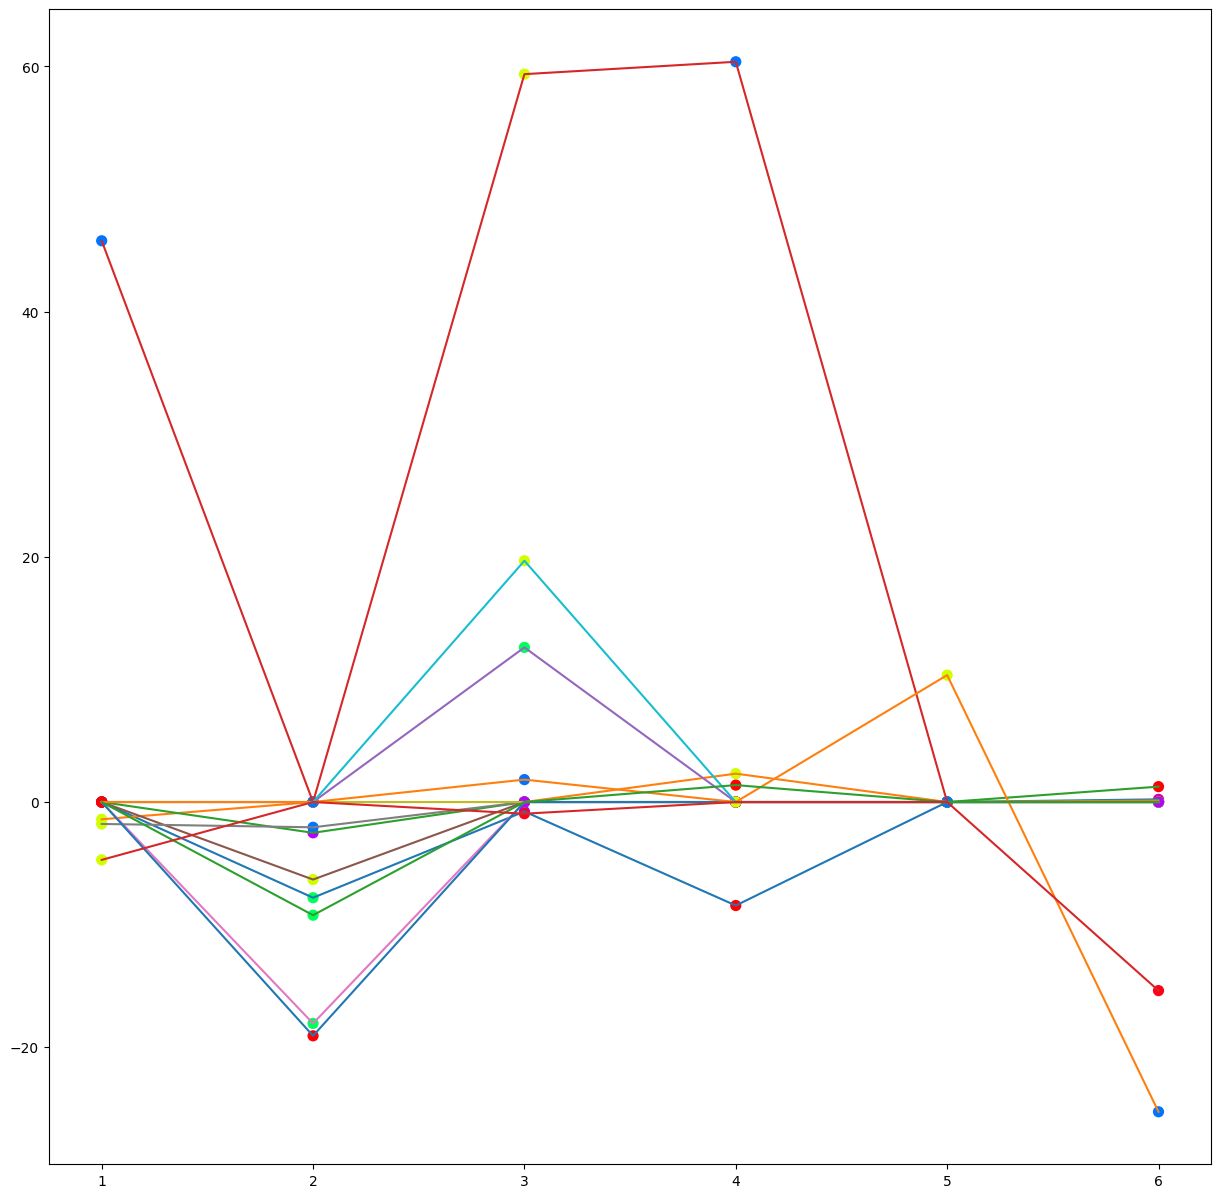

In [99]:
theta = jnp.array(results.last_theta)[:, :, :, model.DIM_LD : 13]


# _ = plt.plot(theta[0,:,-1].T, "o")

xticks = jnp.arange(0, theta.shape[3]) + 1
xticks_rep = jnp.repeat(xticks[:, None], repeats=theta.shape[1], axis=1)


# print(jnp.repeat(xticks[:,None], repeats=  2, axis = 1).shape, theta[1][:,1,:].T.shape)

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.scatter(
    xticks_rep,
    theta[1][:, 1, :].T,
    s=50,
    c=xticks_rep.T,
    cmap="hsv",
)
_ = ax.plot(xticks_rep, theta[1][:, 1, :].T)

ValueError: 'c' argument has 1400 elements, which is inconsistent with 'x' and 'y' with size 1344.

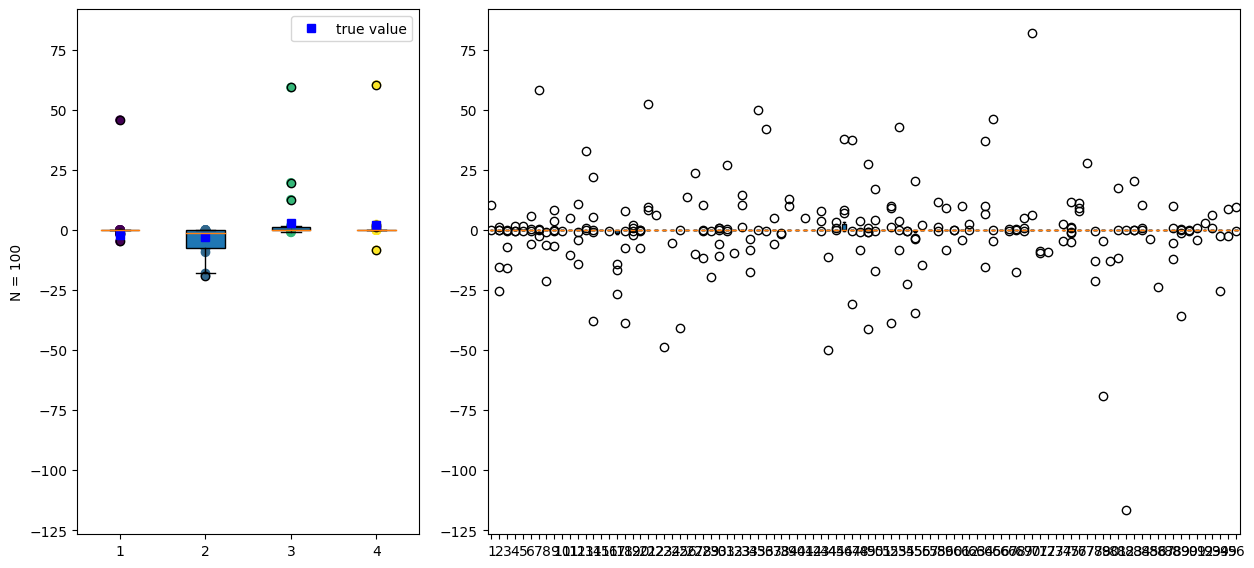

In [70]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = params_star[7:]
theta = jnp.array(results.last_theta)[:, :, :, model.DIM_LD :]

G = GridSpec(len(results), 3)
fig = sdgplt.figure()

n_method = 1

xticks = jnp.arange(0, model.DIMCovCox) + 1
for i in range(len(results)):
    ax = plt.subplot(G[i, 0])

    bp = ax.boxplot(theta[i][:, n_method, :4].T, patch_artist=True)
    ax.scatter(
        jnp.repeat(xticks[:4, None], repeats=theta.shape[1], axis=1),
        theta[1][:, n_method, :4].T,
        c=jnp.repeat(xticks[:4, None], repeats=theta.shape[1], axis=1),
    )

    ax.plot(xticks[:4], params_star_HD[:4], "bs", label="true value")

    ax.legend()
    ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    ax = plt.subplot(G[i, 1:], sharey=ax)
    bp = ax.boxplot(theta[i][:, n_method, 4:].T, patch_artist=True)
    ax.scatter(
        jnp.repeat(xticks[4:, None], repeats=theta.shape[1], axis=1),
        theta[1][:, n_method, 4:].T,
        c=jnp.repeat(jnp.arange(0, theta.shape[1]), repeats=model.DIMCovCox, axis=0).T,
    )

    xticks_nonzero = jnp.arange(1, model.DIMCovCox, step=model.DIMCovCox // 10)
    ax.set_xticks(xticks_nonzero, xticks_nonzero)

ax = plt.subplot(G[0, 0])
ax.set_title(f"Estimation of the 4 non-zero components of beta")
ax = plt.subplot(G[0, 1:], sharey=ax)
ax.set_title(f"Estimation of the remaining zero components of beta")

## Variable selection capacity

We now want to demonstrate our method's ability to perform variable selection. We define the following scenarios, with $N=100$ and $J=5$ fixed, we set the number of covariates increasing $P\in\{50,100,200,250,300,350,600, 800, 1000\}$.

In [ ]:
P = (50, 100, 250, 300, 350, 600, 800, 1000)
results, lbd_set, _, _, scenarios_labels = read_multi_files(N=(100,), P=P)

model = Logistic_JM(N=100, J=5, DIM_HD=max(P))

params_star = jnp.hstack(get_params_star(model.DIM_HD))
params_names = model.params_names

In [ ]:
theta = jnp.array([[r.theta[: model.DIM_LD] for r in res] for res in results])

fig = sdgplt.figure()
for i in range(7):
    ax = fig.add_subplot(3, 3, 1 + i)
    ax.ticklabel_format(style="sci", scilimits=(-3, 3))
    bp = ax.boxplot(theta[:, :, i], patch_artist=True, labels=scenarios_labels)

    for patch in bp["boxes"]:
        patch.set(facecolor=f"C{i}")

    for median in bp["medians"]:
        median.set_color("black")

    ax.axhline(y=params_star[i], color="k", label="true value")

    ax.legend()
    ax.set_title(f"EMV of {params_names[i]} ")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

params_star_HD = params_star[7:]
theta = [jnp.array([r.theta[model.DIM_LD :] for r in res]) for res in results]

G = GridSpec(len(results), 3)
fig = sdgplt.figure()

xticks = jnp.arange(0, max(P)) + 1
for i in range(len(results)):
    ax = plt.subplot(G[i, 0])
    bp = ax.boxplot(theta[i][:, :4].T, patch_artist=True)
    ax.plot(xticks[:4], params_star_HD[:4], "bs", label="true value")
    ax.legend()
    ax.set_ylabel(scenarios_labels[i])
    # == == == == #
    ax = plt.subplot(G[i, 1:], sharey=ax)
    bp = ax.boxplot(theta[i][:, 4:].T, patch_artist=True)

    xticks_nonzero = jnp.arange(1, (P[i] - 4), step=(P[i] - 4) // 20)
    ax.set_xticks(xticks_nonzero, xticks_nonzero)

ax = plt.subplot(G[0, 0])
ax.set_title(f"Estimation of the 4 non-zero components of beta")
ax = plt.subplot(G[0, 1:], sharey=ax)
ax.set_title(f"Estimation of the remaining zero components of beta")

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

theta = [
    jnp.array([(r.theta[model.DIM_LD :] != 0).mean() for r in res]) for res in results
]

fig = sdgplt.figure()
ax = fig.add_subplot(1, 1, 1)
bp = ax.boxplot(theta, patch_artist=True, labels=scenarios_labels)

ax.set_title(f"Percentage of selected components")

In [ ]:
fig = sdgplt.figure()

for i in range(len(results)):
    for j in range(2):
        ax = fig.add_subplot(len(results), 4, 1 + 4 * i + j)
        ax.set_xscale("log")

        ax.plot(
            lbd_set, [res.theta[-1, 7:] for res in results[i][j].regularization_path]
        )

        ax_bic = ax.twinx()
        ax_bic.plot(
            lbd_set,
            results[i][j].bic,
            color="k",
            linewidth=2,
            linestyle="--",
            label="BIC",
        )

        id_min = jnp.nanargmin(results[i][j].bic)
        ax.axvline(x=lbd_set[id_min], color="b", linewidth=2, linestyle="--")

        id_min = jnp.nanargmax(results[i][j].bic[1:] - results[i][j].bic[:-1])
        ax.axvline(x=lbd_set[id_min], color="g", linewidth=2, linestyle="--")

    for j in range(2):
        ax = fig.add_subplot(len(results), 4, 1 + 2 + 4 * i + j)
        ax.set_xscale("log")

        ax.plot(
            lbd_set, [res.theta[-1, :7] for res in results[i][j].regularization_path]
        )

In [ ]:
i = 2
print(P[i])
j = 1
from sdg4varselect.algo import eBIC, BIC

multi_likelihood = jnp.array(
    [res.likelihood for res in results[i][j].regularization_path]
)
multi_theta_HD = jnp.array(
    [res.theta[-1, 7:] for res in results[i][j].regularization_path]
)

bic = BIC(multi_theta_HD, multi_likelihood, model.N)
ebic = eBIC(multi_theta_HD, multi_likelihood, model.N)


def BIC(theta_HD, log_likelihood, n, k_add=0):
    k = (theta_HD != 0).sum(axis=1)
    assert k.shape == log_likelihood.shape

    return -2 * log_likelihood + (k + k_add) * jnp.log(n)


bicJ = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1))

bic5 = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1), k_add=5)

bic6 = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1), k_add=6)

bic7 = BIC(multi_theta_HD, multi_likelihood, model.N * (model.J + 1), k_add=7)

fig = sdgplt.figure()
ax = fig.add_subplot(2, 1, 1)
ax.set_xscale("log")
ax.plot(lbd_set, multi_theta_HD)
ax.set_title(f"Regularization path for N={model.N},P={P[i]},J={model.J}")

ax = fig.add_subplot(2, 1, 2)
ax.set_xscale("log")

ax.plot(lbd_set, bic, color=f"C{5}", linewidth=2, linestyle="--", label="BIC N")
ax.plot(lbd_set, ebic, color=f"C{0}", linewidth=2, linestyle="--", label="eBIC")
ax.plot(lbd_set, bicJ, color=f"C{1}", linewidth=2, linestyle="--", label="bic (J+1)*N")
ax.plot(lbd_set, bic5, color=f"C{2}", linewidth=2, linestyle="--", label="bic5")
ax.plot(lbd_set, bic6, color=f"C{3}", linewidth=2, linestyle="--", label="bic6")
ax.plot(lbd_set, bic7, color=f"C{4}", linewidth=2, linestyle="--", label="bic7")


ax.set_title("Different criteria for the selection of the regularization parameter")
ax.legend()

## Censoring Effect

We now want to demonstrate our method's ability to perform variable selection. We define the following scenarios, with $N=100$ and $J=5$ fixed, we set the number of covariates increasing $P\in\{50,100,200,250,300,350,600, 800, 1000\}$.

In [ ]:
results, lbd_set, _, _, scenarios_labels = read_multi_files(N=(50,), P=(8,), S=2)
model = Logistic_JM(N=50, J=5, DIM_HD=8)

In [ ]:
results[i][j].regularization_path[0].theta[-1].shape